In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from pandas.api.types import is_numeric_dtype
import warnings
import optuna
import joblib
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import RFE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, confusion_matrix, roc_curve, auc
import xgboost as xgb
from tabulate import tabulate
import itertools
import os

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


c:\Users\adity\OneDrive\Attachments\Desktop\IDS_WEB_APP\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import os

os.chdir(r"C:\Users\adity\OneDrive\Attachments\Desktop\IDS_WEB_APP")

print(os.getcwd())

train = pd.read_csv('KDDTrain+.txt')
test = pd.read_csv('KDDTest+.txt')

print(train.head())
print(test.head())

C:\Users\adity\OneDrive\Attachments\Desktop\IDS_WEB_APP
   0  tcp ftp_data   SF  491   0.1  0.2  0.3  0.4  0.5  ...  0.17  0.03  \
0  0  udp    other   SF  146     0    0    0    0    0  ...  0.00  0.60   
1  0  tcp  private   S0    0     0    0    0    0    0  ...  0.10  0.05   
2  0  tcp     http   SF  232  8153    0    0    0    0  ...  1.00  0.00   
3  0  tcp     http   SF  199   420    0    0    0    0  ...  1.00  0.00   
4  0  tcp  private  REJ    0     0    0    0    0    0  ...  0.07  0.07   

   0.17.1  0.00.6  0.00.7  0.00.8  0.05  0.00.9   normal  20  
0    0.88    0.00    0.00    0.00   0.0    0.00   normal  15  
1    0.00    0.00    1.00    1.00   0.0    0.00  neptune  19  
2    0.03    0.04    0.03    0.01   0.0    0.01   normal  21  
3    0.00    0.00    0.00    0.00   0.0    0.00   normal  21  
4    0.00    0.00    0.00    0.00   1.0    1.00  neptune  21  

[5 rows x 43 columns]
   0   tcp   private   REJ    0.1    0.2  0.3  0.4  0.5  0.6  ...  0.04.1  \
0  0   tcp   pr

# Data Preprocessing & EDA

In [119]:
import pandas as pd
import os

os.chdir(r"C:\Users\adity\OneDrive\Attachments\Desktop\IDS_WEB_APP")

train = pd.read_csv('KDDTrain+.txt')
test = pd.read_csv('KDDTest+.txt')

print(train.head())
print(test.head())

   0  tcp ftp_data   SF  491   0.1  0.2  0.3  0.4  0.5  ...  0.17  0.03  \
0  0  udp    other   SF  146     0    0    0    0    0  ...  0.00  0.60   
1  0  tcp  private   S0    0     0    0    0    0    0  ...  0.10  0.05   
2  0  tcp     http   SF  232  8153    0    0    0    0  ...  1.00  0.00   
3  0  tcp     http   SF  199   420    0    0    0    0  ...  1.00  0.00   
4  0  tcp  private  REJ    0     0    0    0    0    0  ...  0.07  0.07   

   0.17.1  0.00.6  0.00.7  0.00.8  0.05  0.00.9   normal  20  
0    0.88    0.00    0.00    0.00   0.0    0.00   normal  15  
1    0.00    0.00    1.00    1.00   0.0    0.00  neptune  19  
2    0.03    0.04    0.03    0.01   0.0    0.01   normal  21  
3    0.00    0.00    0.00    0.00   0.0    0.00   normal  21  
4    0.00    0.00    0.00    0.00   1.0    1.00  neptune  21  

[5 rows x 43 columns]
   0   tcp   private   REJ    0.1    0.2  0.3  0.4  0.5  0.6  ...  0.04.1  \
0  0   tcp   private   REJ      0      0    0    0    0    0  ...    0.

In [120]:
train.info()
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   0         125972 non-null  int64  
 1   tcp       125972 non-null  str    
 2   ftp_data  125972 non-null  str    
 3   SF        125972 non-null  str    
 4   491       125972 non-null  int64  
 5   0.1       125972 non-null  int64  
 6   0.2       125972 non-null  int64  
 7   0.3       125972 non-null  int64  
 8   0.4       125972 non-null  int64  
 9   0.5       125972 non-null  int64  
 10  0.6       125972 non-null  int64  
 11  0.7       125972 non-null  int64  
 12  0.8       125972 non-null  int64  
 13  0.9       125972 non-null  int64  
 14  0.10      125972 non-null  int64  
 15  0.11      125972 non-null  int64  
 16  0.12      125972 non-null  int64  
 17  0.13      125972 non-null  int64  
 18  0.14      125972 non-null  int64  
 19  0.15      125972 non-null  int64  
 20  0.16      12597

In [121]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in train.columns:
    if train[col].dtype == 'object':
        train[col] = encoder.fit_transform(train[col])

for col in test.columns:
    if test[col].dtype == 'object':
        test[col] = encoder.fit_transform(test[col])

print(train.head())
print(test.head())

   0  tcp ftp_data   SF  491   0.1  0.2  0.3  0.4  0.5  ...  0.17  0.03  \
0  0  udp    other   SF  146     0    0    0    0    0  ...  0.00  0.60   
1  0  tcp  private   S0    0     0    0    0    0    0  ...  0.10  0.05   
2  0  tcp     http   SF  232  8153    0    0    0    0  ...  1.00  0.00   
3  0  tcp     http   SF  199   420    0    0    0    0  ...  1.00  0.00   
4  0  tcp  private  REJ    0     0    0    0    0    0  ...  0.07  0.07   

   0.17.1  0.00.6  0.00.7  0.00.8  0.05  0.00.9   normal  20  
0    0.88    0.00    0.00    0.00   0.0    0.00   normal  15  
1    0.00    0.00    1.00    1.00   0.0    0.00  neptune  19  
2    0.03    0.04    0.03    0.01   0.0    0.01   normal  21  
3    0.00    0.00    0.00    0.00   0.0    0.00   normal  21  
4    0.00    0.00    0.00    0.00   1.0    1.00  neptune  21  

[5 rows x 43 columns]
   0   tcp   private   REJ    0.1    0.2  0.3  0.4  0.5  0.6  ...  0.04.1  \
0  0   tcp   private   REJ      0      0    0    0    0    0  ...    0.

In [122]:
train.describe()

,0,491,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,25,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,20
count,125972.000000,1.259720e+05,1.259720e+05,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,...,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000
mean,287.146929,4.556710e+04,1.977927e+04,0.000198,0.022688,0.000111,0.204411,0.001222,0.395739,0.279253,...,115.653725,0.521244,0.082952,0.148379,0.032543,0.284455,0.278487,0.118832,0.120241,19.504056
std,2604.525522,5.870354e+06,4.021285e+06,0.014086,0.253531,0.014366,2.149977,0.045239,0.489011,23.942137,...,110.702886,0.448950,0.188922,0.308998,0.112564,0.444785,0.445670,0.306559,0.319460,2.291512
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [123]:
train.describe(include='object')

,tcp,ftp_data,SF,normal
count,125972,125972,125972,125972
unique,3,70,11,23
top,tcp,http,SF,normal
freq,102688,40338,74944,67342


In [124]:
print('Number of data points: ',train.shape[0])
print('Number of features: ', train.shape[1])

Number of data points:  125972
Number of features:  43


In [125]:
# Checking for null values
value=0
for index, value in train.isnull().sum().items():
    if value > 0:
        print(f"There are {value} missing values in column - {index}")
if value == 0:
    print("No Null Values Found")

No Null Values Found


In [126]:
#Checking for duplicates
print(f"Number of duplicate rows: {train.duplicated().sum()}")

Number of duplicate rows: 0


In [127]:
missing_data=0
total = train.shape[0]
missing_columns = [col for col in train.columns if train[col].isnull().sum() > 0]
for col in missing_columns:
    null_count = train[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")
    missing_data=1
if missing_data == 0:
    print("No Missing data Found!")

No Missing data Found!


In [128]:
#Finding Outliers
#for col in train:
 #    if col != 'class' and is_numeric_dtype(train[col]):
  #       fig, ax = plt.subplots(2, 1, figsize=(12, 8))
   #      g1 = sns.boxplot(x = train[col], ax=ax[0])
    #     g2 = sns.scatterplot(data=train, x=train[col],y=train['class'], ax=ax[1])
#No Outliers Found         

# Exploratory Data Analysis

In [129]:
column_names = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes',
'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
'is_host_login','is_guest_login','count','srv_count','serror_rate',
'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
'diff_srv_rate','srv_diff_host_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','class','difficulty'
]

train = pd.read_csv('KDDTrain+.txt', names=column_names)
test = pd.read_csv('KDDTest+.txt', names=column_names)

print(train.head())
print(test.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [130]:
dist = train['class'].value_counts()

for name, count in dist.items():
    print(f"Number of data points in class: {name.center(17)} is", end=' ')
    print(f"{count} ({np.round(count / sum(dist) * 100, 3)}%)")

Number of data points in class:       normal      is 67343 (53.458%)
Number of data points in class:      neptune      is 41214 (32.717%)
Number of data points in class:       satan       is 3633 (2.884%)
Number of data points in class:      ipsweep      is 3599 (2.857%)
Number of data points in class:     portsweep     is 2931 (2.327%)
Number of data points in class:       smurf       is 2646 (2.1%)
Number of data points in class:        nmap       is 1493 (1.185%)
Number of data points in class:        back       is 956 (0.759%)
Number of data points in class:      teardrop     is 892 (0.708%)
Number of data points in class:    warezclient    is 890 (0.707%)
Number of data points in class:        pod        is 201 (0.16%)
Number of data points in class:    guess_passwd   is 53 (0.042%)
Number of data points in class:  buffer_overflow  is 30 (0.024%)
Number of data points in class:    warezmaster    is 20 (0.016%)
Number of data points in class:        land       is 18 (0.014%)
Number

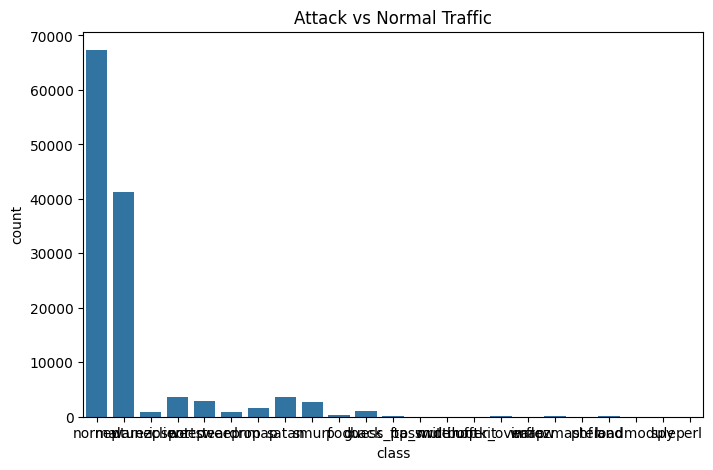

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x=train['class'])

plt.title("Attack vs Normal Traffic")
plt.show()

# LABEL ENCODING

In [132]:
encoding_dict = {"protocol_type":LabelEncoder(), 
                 "service":LabelEncoder(), 
                 "flag":LabelEncoder()}
def le(df):
    for col in df.columns:
        if df[col].dtype == 'object':
                label_encoder = LabelEncoder()
                df[col] = label_encoder.fit_transform(df[col])

le(train)
le(test)

In [133]:
joblib.dump(encoding_dict, 'encoders.joblib')

['encoders.joblib']

In [134]:
train.drop(['num_outbound_cmds'], axis=1, inplace=True)
test.drop(['num_outbound_cmds'], axis=1, inplace=True)
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [135]:
X_train = train.drop(['class'], axis=1)
y_train = train['class']

X_test = test.drop(['class'], axis=1)
y_test = test['class']

print(X_train.shape)
print(X_test.shape)


(125973, 41)
(22544, 41)


In [136]:
from sklearn.preprocessing import LabelEncoder

for col in X_train.columns:
    if X_train[col].dtype == 'object':

        le = LabelEncoder()

        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))

print("Encoding Done")

Encoding Done


In [137]:
from sklearn.preprocessing import LabelEncoder

for col in X_train.columns:
    if X_train[col].dtype == 'object':

        le = LabelEncoder()

        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))

print("Encoding Done")

Encoding Done


# Feature selection

In [1]:
X_train = train.drop(['class'], axis=1)
y_train = train['class']

X_test = test.drop(['class'], axis=1)
y_test = test['class']

NameError: name 'train' is not defined

In [139]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [140]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# Sirf numeric columns lo
X_train_numeric = X_train.select_dtypes(include=['number'])
X_test_numeric = X_test.select_dtypes(include=['number'])

selector = SelectKBest(score_func=chi2, k=20)

X_train_selected = selector.fit_transform(X_train_numeric, y_train)
X_test_selected = selector.transform(X_test_numeric)

print("Original Shape:", X_train_numeric.shape)
print("Selected Shape:", X_train_selected.shape)

Original Shape: (125973, 38)
Selected Shape: (125973, 20)


# Split and Scale Data

In [141]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [142]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.fit_transform(X_test[col].astype(str))

print("All columns encoded")

All columns encoded


In [143]:
scale = StandardScaler()

X_train_selected = scale.fit_transform(X_train_selected)
X_test_selected = scale.transform(X_test_selected)

print("Scaling Done")

Scaling Done


In [144]:
x_train, x_test, y_train, y_test = train_test_split(
    X_train_selected, y_train,
    train_size=0.70,
    random_state=2
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.20,
    random_state=2
)

print("Split Done")

Split Done


# Decision Tree Classifier

In [145]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier()

dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9907917019475021


In [146]:
import optuna

In [147]:
def objective(trial):

    max_depth = trial.suggest_int('dt_max_depth', 3, 10)

    clf = DecisionTreeClassifier(
        max_depth=max_depth
    )

    clf.fit(x_train, y_train)

    y_pred = clf.predict(x_test)

    acc = accuracy_score(y_test, y_pred)

    return acc

In [148]:
study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective, n_trials=30)
print(study_dt.best_trial)

FrozenTrial(number=26, state=<TrialState.COMPLETE: 1>, values=[0.9894686706181203], datetime_start=datetime.datetime(2026, 5, 14, 18, 24, 10, 930692), datetime_complete=datetime.datetime(2026, 5, 14, 18, 24, 11, 360383), params={'dt_max_depth': 10}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'dt_max_depth': IntDistribution(high=10, log=False, low=3, step=1)}, trial_id=26, value=None)


In [149]:
from sklearn.metrics import log_loss
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [150]:


# Initialize the Decision Tree classifier with adjusted parameters to reduce complexity
dt = DecisionTreeClassifier(
    max_features=study_dt.best_trial.params.get('dt_max_features', None),
    max_depth=study_dt.best_trial.params.get('dt_max_depth', 5),  # Set a lower max depth
    min_samples_leaf=5  # Ensure each leaf has at least 5 samples
)

# Fit the model on the training data
dt.fit(x_train, y_train)

# Predictions for training, validation, and test sets
y_train_pred = dt.predict(x_train)
y_val_pred = dt.predict(x_val)
y_test_pred = dt.predict(x_test)

# Calculate training accuracy
dt_train = accuracy_score(y_train, y_train_pred)

# Validation accuracy
dt_val = accuracy_score(y_val, y_val_pred)

# Test accuracy
dt_test = accuracy_score(y_test, y_test_pred)

# Validation loss (log loss)
y_val_prob = dt.predict_proba(x_val)
val_loss = log_loss(y_val, y_val_prob, labels=dt.classes_)

# Precision, Recall, and F1 Score on the validation set
precision = precision_score(y_val, y_val_pred, average='weighted')
recall = recall_score(y_val, y_val_pred, average='weighted')
f1 = f1_score(y_val, y_val_pred, average='weighted')

# Print the results
print(f"Training Accuracy: {dt_train}")
print(f"Validation Accuracy: {dt_val}")
print(f"Test Accuracy: {dt_test}")
print(f"Validation Loss: {val_loss}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Training Accuracy: 0.9905165570424133
Validation Accuracy: 0.9891137948630719
Test Accuracy: 0.9888071549534293
Validation Loss: 0.06798285817469389
Precision: 0.9894083109943275
Recall: 0.9891137948630719
F1 Score: 0.9885693931527445


In [151]:
import joblib

In [152]:
joblib.dump(dt,"decision_tree.pkl")

['decision_tree.pkl']

In [153]:
import matplotlib.pyplot as plt
from sklearn import tree

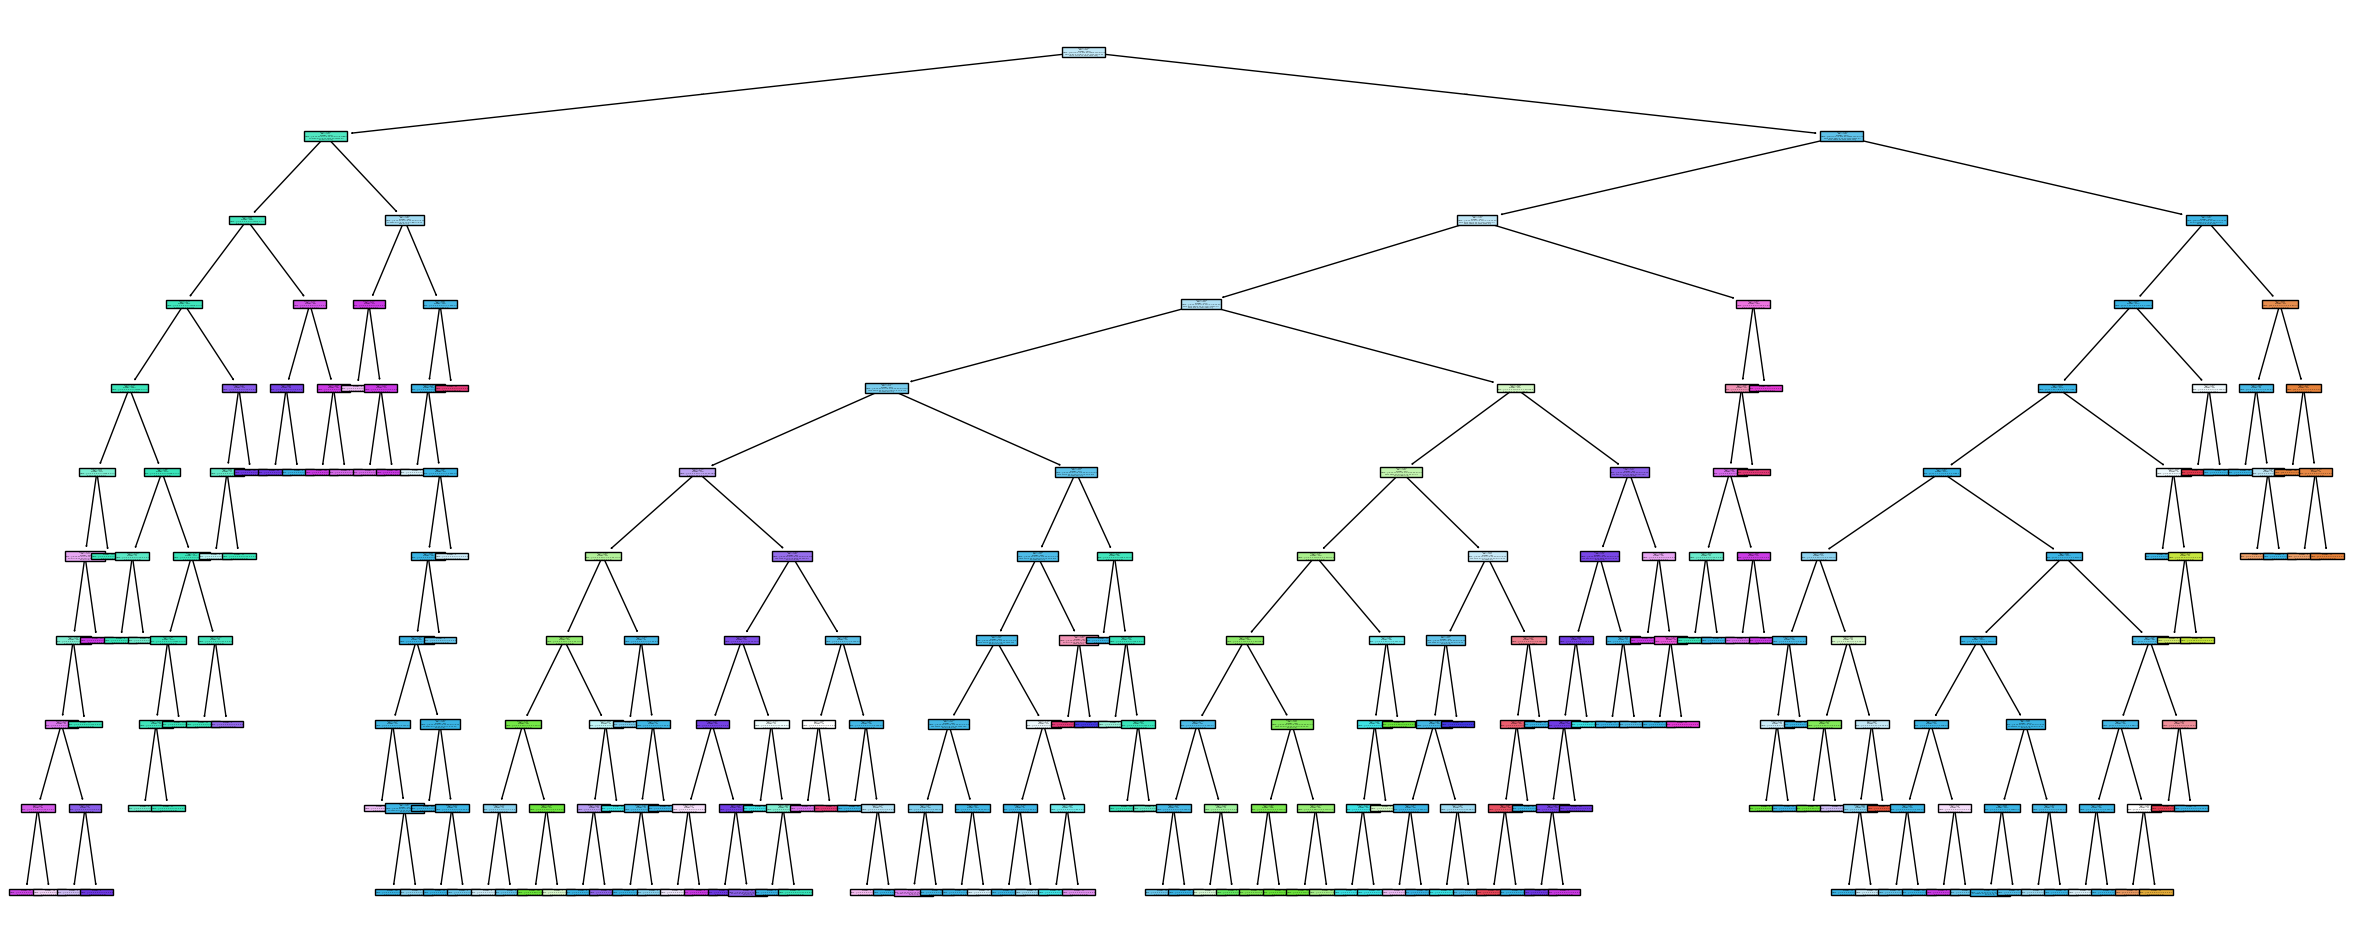

In [154]:
fig = plt.figure(figsize = (30,12))
tree.plot_tree(dt, filled=True);
plt.show()

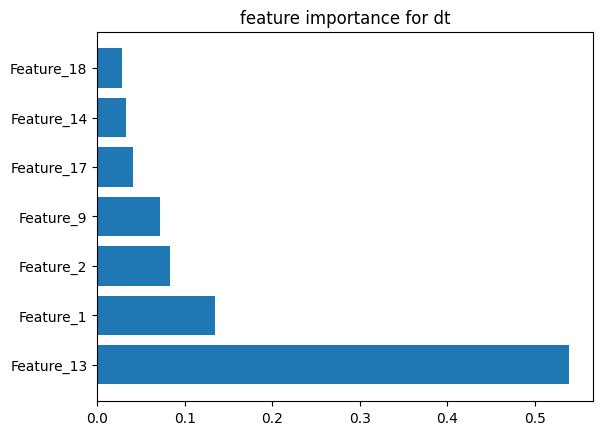

In [155]:
#RESULT VISUALIZATION AND RESULT ANALYSIS
def f_importance(coef, names, top=-1):
    imp = coef
    imp, names = zip(*sorted(list(zip(imp, names))))

    # Show all features
    if top == -1:
        top = len(names)

    plt.barh(range(top), imp[::-1][0:top], align='center')
    plt.yticks(range(top), names[::-1][0:top])
    plt.title('feature importance for dt')
    plt.show()
features_names = [f"Feature_{i}" for i in range(len(dt.feature_importances_))]
f_importance(abs(dt.feature_importances_), features_names, top=7)

In [156]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

In [157]:
import numpy as np

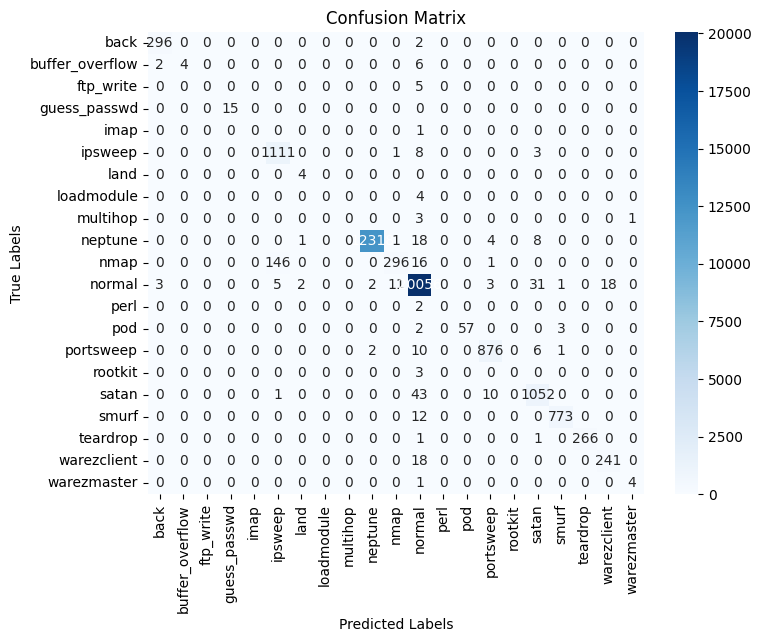

In [158]:


# 1. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# 2. ROC Curve and AUC (only for binary classification)
if len(np.unique(y_train)) == 2:  # Binary classification check
    y_test_prob = dt.predict_proba(x_test)[:, 1]  # Probability of the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()






# Random Forest Classifier

In [159]:
def objective(trial):
    rf_max_depth = trial.suggest_int('rf_max_depth', 2, 32, log=False)
    rf_max_features = trial.suggest_int('rf_max_features', 2, 10, log=False)
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 3, 20, log=False)
    classifier_obj = RandomForestClassifier(max_features = rf_max_features, max_depth = rf_max_depth, n_estimators = rf_n_estimators)
    classifier_obj.fit(x_train, y_train)
    accuracy = classifier_obj.score(x_test, y_test)
    return accuracy

In [160]:
from sklearn.ensemble import RandomForestClassifier

In [161]:
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective, n_trials=30)
print(study_rf.best_trial)

FrozenTrial(number=19, state=<TrialState.COMPLETE: 1>, values=[0.9932260795935648], datetime_start=datetime.datetime(2026, 5, 14, 18, 24, 42, 363128), datetime_complete=datetime.datetime(2026, 5, 14, 18, 24, 43, 802558), params={'rf_max_depth': 15, 'rf_max_features': 9, 'rf_n_estimators': 12}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'rf_max_depth': IntDistribution(high=32, log=False, low=2, step=1), 'rf_max_features': IntDistribution(high=10, log=False, low=2, step=1), 'rf_n_estimators': IntDistribution(high=20, log=False, low=3, step=1)}, trial_id=19, value=None)


In [162]:

rf = RandomForestClassifier(
    max_features=study_rf.best_trial.params['rf_max_features'], 
    max_depth=study_rf.best_trial.params['rf_max_depth'], 
    n_estimators=study_rf.best_trial.params['rf_n_estimators'],
    min_samples_split=5,          # Minimum number of samples required to split an internal node
    min_samples_leaf=4,           # Minimum number of samples required to be at a leaf node
    max_samples=0.8,              # Use 80% of the data for each tree
    random_state=2                # Ensures reproducibility
)

# Fit the model on the training data
rf.fit(x_train, y_train)

# Predictions for training, validation, and test sets
y_train_pred = rf.predict(x_train)
y_val_pred = rf.predict(x_val)
y_test_pred = rf.predict(x_test)

# Calculate accuracies
rn_train = accuracy_score(y_train, y_train_pred)
rn_val = accuracy_score(y_val, y_val_pred)
rn_test = accuracy_score(y_test, y_test_pred)

# Validation loss (log loss) for y_test
y_test_prob = rf.predict_proba(x_test)
val_loss = log_loss(y_test, y_test_prob, labels=rf.classes_)

# Print results
print("Training Accuracy:", rn_train)
print("Validation Accuracy:", rn_val)
print("Test Accuracy:", rn_test)
print("Validation Log Loss:", val_loss)

# Precision, Recall, and F1 Score on the validation set
precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

# Print the results
print(f"Training Accuracy: {rn_train}")
print(f"Validation Accuracy: {rn_val}")
print(f"Test Accuracy: {rn_test}")
print(f"Validation Loss: {val_loss}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")




Training Accuracy: 0.9934367203447494
Validation Accuracy: 0.9919487441174804
Test Accuracy: 0.9916384419983065
Validation Log Loss: 0.03515663356862717
Training Accuracy: 0.9934367203447494
Validation Accuracy: 0.9919487441174804
Test Accuracy: 0.9916384419983065
Validation Loss: 0.03515663356862717
Precision: 0.9914698553780893
Recall: 0.9916384419983065
F1 Score: 0.9910496481394278


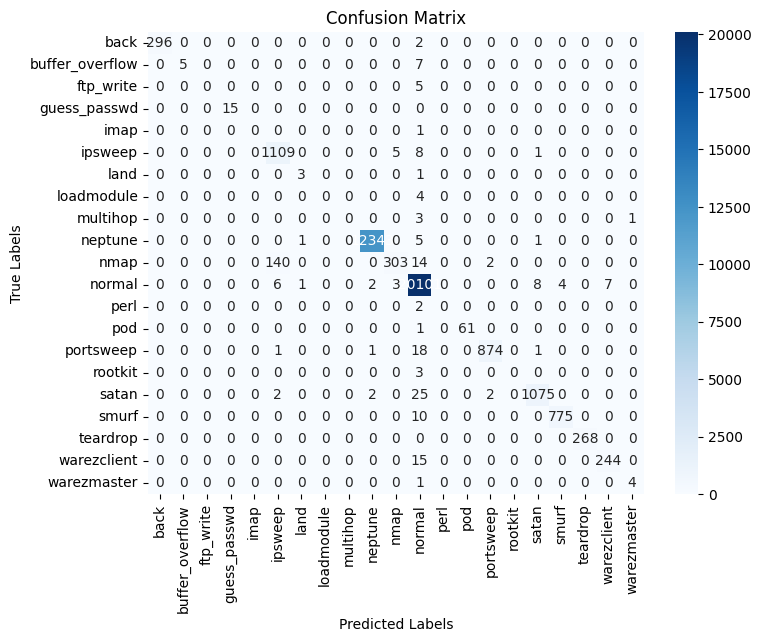

In [163]:
#RESULT ANALYSIS AND VISUALIZATION
# 1. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# 2. ROC Curve and AUC (only for binary classification)
if len(np.unique(y_train)) == 2:  # Binary classification check
    y_test_prob = rf.predict_proba(x_test)[:, 1]  # Probability of the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

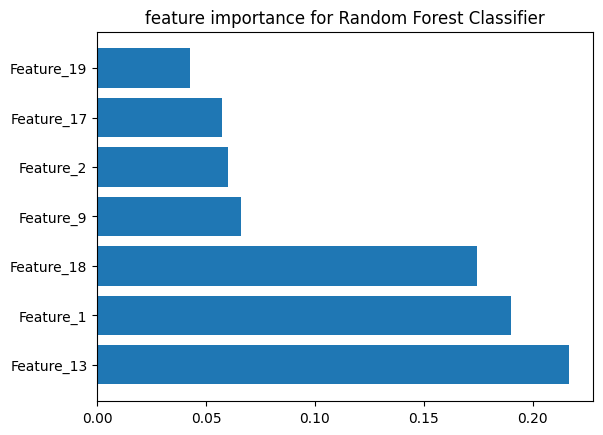

In [164]:


def f_importance(coef, names, top=-1):
    imp = coef
    imp, names = zip(*sorted(list(zip(imp, names))))

    # Show all features
    if top == -1:
        top = len(names)

    plt.barh(range(top), imp[::-1][0:top], align='center')
    plt.yticks(range(top), names[::-1][0:top])
    plt.title('feature importance for Random Forest Classifier')
    plt.show()

# whatever your featuresfeatures_names = feature_names are called


# Specify your top n features you want to visualize.
# You can also discard the abs() function 
# if you are interested in negative contribution of features
f_importance(abs(rf.feature_importances_), features_names, top=7)

# GradientBoostingClassifier

In [165]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
SKGB = GradientBoostingClassifier(random_state=42)
SKGB.fit(x_train, y_train)

In [ ]:


# Initialize the Gradient Boosting classifier with manually chosen parameters
gb = GradientBoostingClassifier(
    max_depth=5,  # Example parameter
    n_estimators=100,  # Example parameter
    learning_rate=0.05  # Example parameter
)

# Fit the model
gb.fit(x_train, y_train)

# Predictions for training, validation, and test sets
y_train_pred = gb.predict(x_train)
y_val_pred = gb.predict(x_val)
y_test_pred = gb.predict(x_test)

# Calculate training, validation, and test accuracy
gb_train = accuracy_score(y_train, y_train_pred)
gb_val = accuracy_score(y_val, y_val_pred)
gb_test = accuracy_score(y_test, y_test_pred)

# Calculate validation loss
y_test_prob = gb.predict_proba(x_test)
val_loss = log_loss(y_test, y_test_prob, labels=gb.classes_)

# Calculate Precision, Recall, and F1 Score on the validation set
precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

# Print results
print(f"Training Accuracy: {gb_train}")
print(f"Validation Accuracy: {gb_val}")
print(f"Test Accuracy: {gb_test}")
print(f"Validation Loss: {val_loss}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")




Training Accuracy: 0.9963143569970515
Validation Accuracy: 0.9940466065657425
Test Accuracy: 0.9934113039796783
Validation Loss: 0.041122381304876734
Precision: 0.9935043279944608
Recall: 0.9934113039796783
F1 Score: 0.9930680890081859


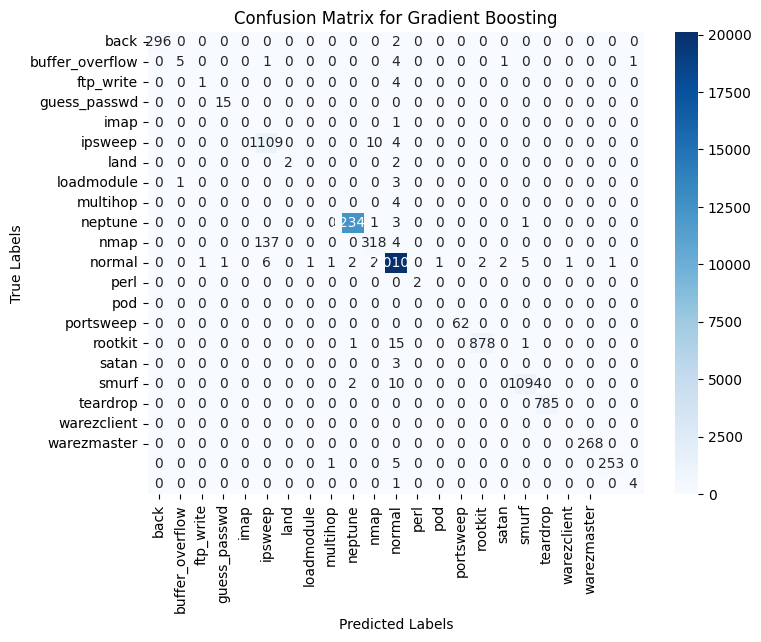

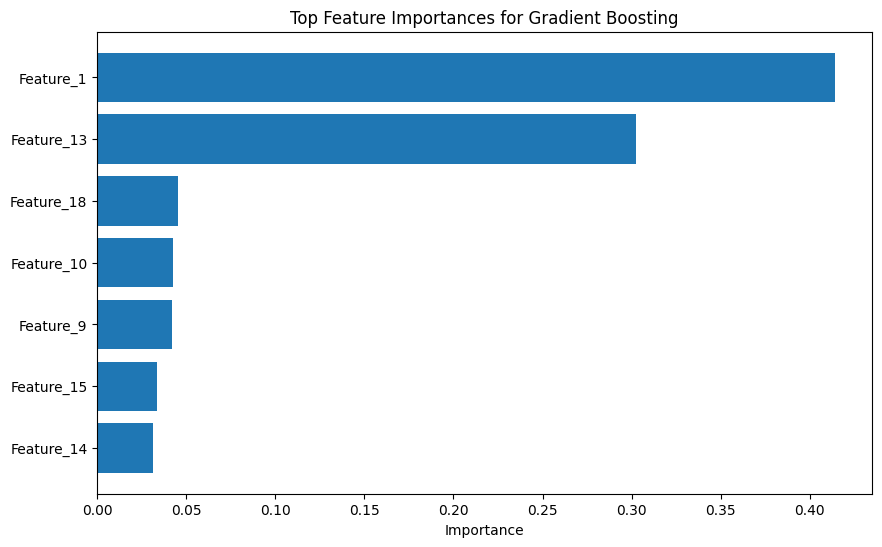

In [ ]:
#RESULT ANALYSIS AND VISUALIZATION
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Gradient Boosting')
plt.show()

# ROC Curve and AUC (for binary classification)
if len(np.unique(y_train)) == 2:  # Check if it's binary classification
    y_test_prob = gb.predict_proba(x_test)[:, 1]  # Probability of the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Gradient Boosting')
    plt.legend()
    plt.show()

# Feature Importance Plot
feature_importances = gb.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot top n feature importances
top_n = 7
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), feature_importances[sorted_idx][:top_n], align='center')
plt.yticks(range(top_n), np.array(features_names)[sorted_idx][:top_n])
plt.xlabel('Importance')
plt.title('Top Feature Importances for Gradient Boosting')
plt.gca().invert_yaxis()
plt.show()

# XGBoost Gradient Boosting Model

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

In [ ]:
from xgboost import XGBClassifier

In [ ]:

# Initialize the XGBoost classifier
xgb_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=23,
    eval_metric='mlogloss',
    max_depth=5,
    n_estimators=100,
    subsample=0.9,
    colsample_bytree=0.9,
    learning_rate=0.1,
    reg_alpha=1.0,
    reg_lambda=1.0
)

# Train model
xgb_clf.fit(x_train, y_train_encoded)

# Predictions
y_train_pred = xgb_clf.predict(x_train)
y_val_pred = xgb_clf.predict(x_val)
y_test_pred = xgb_clf.predict(x_test)

# Accuracy
xgb_train = accuracy_score(y_train_encoded, y_train_pred)
xgb_val = accuracy_score(y_val_encoded, y_val_pred)
xgb_test = accuracy_score(y_test_encoded, y_test_pred)

# Precision, Recall, F1
precision = precision_score(y_test_encoded, y_test_pred, average='weighted')
recall = recall_score(y_test_encoded, y_test_pred, average='weighted')
f1 = f1_score(y_test_encoded, y_test_pred, average='weighted')

# Print results
print(f"Training Accuracy: {xgb_train}")
print(f"Validation Accuracy: {xgb_val}")
print(f"Test Accuracy: {xgb_test}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Training Accuracy: 0.995293717396235
Validation Accuracy: 0.9936497136701253
Test Accuracy: 0.9937023708721423
Precision: 0.9935409530727985
Recall: 0.9937023708721423
F1 Score: 0.993204997287563


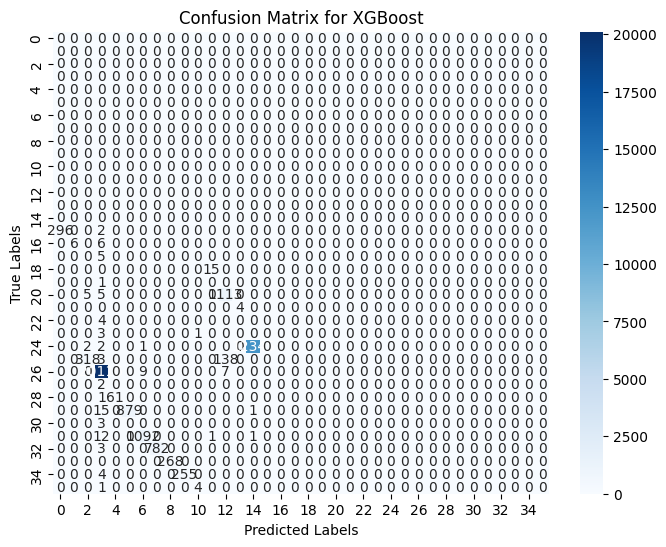

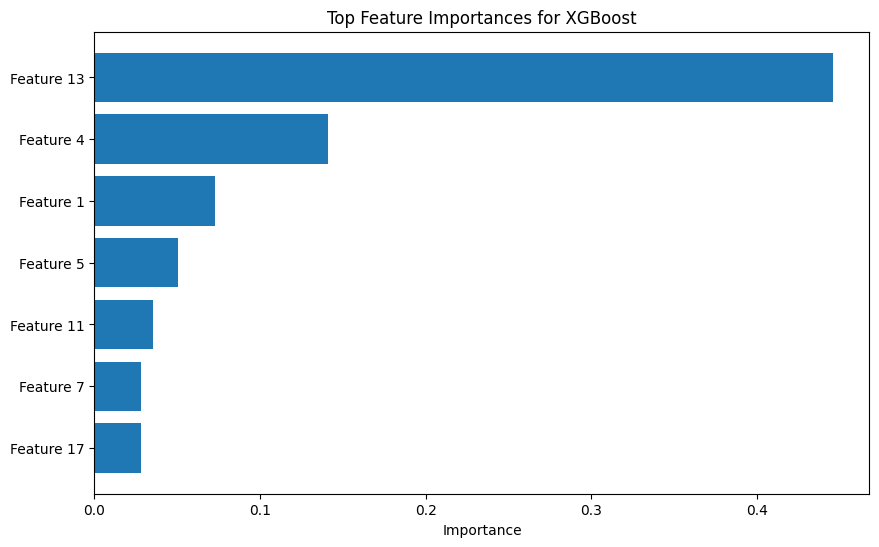

In [ ]:
#RESULT ANALYSIS AND VISUALIZATION
# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test.astype(str), y_test_pred.astype(str))

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for XGBoost')
plt.show()

# ROC Curve and AUC (for binary classification)
if len(np.unique(y_train)) == 2:  # Check if it's binary classification
    y_test_prob = xgb_clf.predict_proba(x_test)[:, 1]  # Probability of the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for XGBoost')
    plt.legend()
    plt.show()

# Feature Importance Plot for XGBoost
feature_importances = xgb_clf.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot top n feature importances
top_n = 7  # Adjust this value to see more or fewer features
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), feature_importances[sorted_idx][:top_n], align='center')
plt.yticks(range(top_n), [f"Feature {i}" for i in sorted_idx[:top_n]])
plt.xlabel('Importance')
plt.title('Top Feature Importances for XGBoost')
plt.gca().invert_yaxis()
plt.show()



# Summary

In [ ]:
from tabulate import tabulate

╒═══════════════╤═══════════════╤══════════════╕
│ Model         │   Train Score │   Test Score │
╞═══════════════╪═══════════════╪══════════════╡
│ Decision Tree │      0.990517 │     0.988834 │
├───────────────┼───────────────┼──────────────┤
│ Random Forest │      0.994145 │     0.992326 │
├───────────────┼───────────────┼──────────────┤
│ GBM           │      0.996314 │     0.993411 │
├───────────────┼───────────────┼──────────────┤
│ XGBM          │      0.995294 │     0.993702 │
╘═══════════════╧═══════════════╧══════════════╛


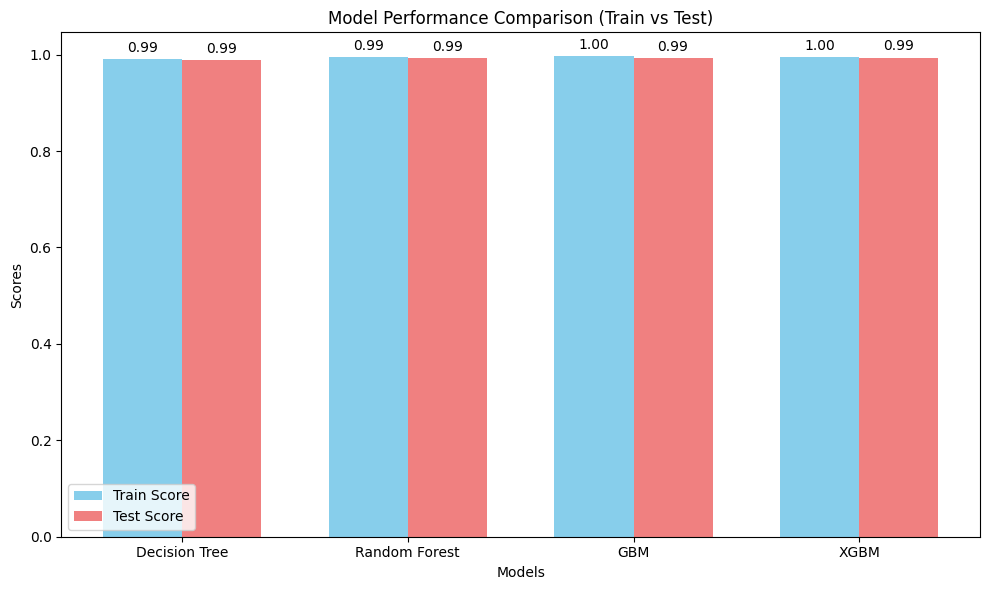

In [ ]:

# Data for comparison
data = [
    ["Decision Tree", dt_train, dt_test], 
    ["Random Forest", rn_train, rn_test], 
    ["GBM", gb_train, gb_test], 
    ["XGBM", xgb_train, xgb_test]
]

# Column names
col_names = ["Model", "Train Score", "Test Score"]

# Display the table
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

# Create bar chart for better visualization
models = [row[0] for row in data]  # Extract model names
train_scores = [row[1] for row in data]  # Extract train scores
test_scores = [row[2] for row in data]  # Extract test scores

# Set up the bar chart
x = np.arange(len(models))  # The label locations
width = 0.35  # The width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
rects1 = ax.bar(x - width/2, train_scores, width, label='Train Score', color='skyblue')
rects2 = ax.bar(x + width/2, test_scores, width, label='Test Score', color='lightcoral')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison (Train vs Test)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Annotate the bars with the height values
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Add labels to both train and test score bars
add_labels(rects1)
add_labels(rects2)

# Show the plot
plt.tight_layout()
plt.show()
